## NB3
Goal

## (1) Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set(style='whitegrid')

## (2) Load RFM 

In [2]:
rfm = pd.read_csv("C:/Projects/08_Customer_Intellignece_System/data/rfm_table_final.csv")
rfm.head()

,Unnamed: 0,CustomerID,Recency,Frequency,Monetary,Recency_log,Frequency_log,Monetary_log
0,0,12346.0,326,1,77183.60,5.789960,0.693147,11.253955
1,1,12347.0,2,7,4310.00,1.098612,2.079442,8.368925
2,2,12348.0,75,4,1797.24,4.330733,1.609438,7.494564
3,3,12349.0,19,1,1757.55,2.995732,0.693147,7.472245
4,4,12350.0,310,1,334.40,5.739793,0.693147,5.815324


## (3) Select the features

In [3]:
X = rfm[['Recency_log', 'Frequency_log', 'Monetary_log']]

## (4) Scaling

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## (5) Elbow Method (Find K)

In [5]:
inertia = []
K = range(1,11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

c:\Users\shwey\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\shwey\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\shwey\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\shwey\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

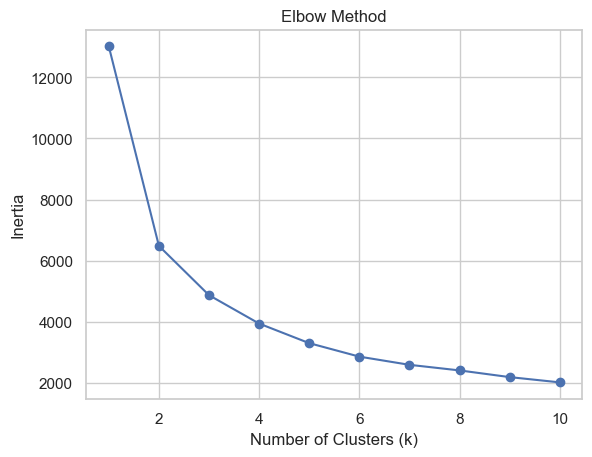

In [6]:
# Plot
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## (6) Apply K Means

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

c:\Users\shwey\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=17.
  warnings.warn(


## (7) Check Result

In [9]:
rfm.head()

,Unnamed: 0,CustomerID,Recency,Frequency,Monetary,Recency_log,Frequency_log,Monetary_log,Cluster
0,0,12346.0,326,1,77183.60,5.789960,0.693147,11.253955,2
1,1,12347.0,2,7,4310.00,1.098612,2.079442,8.368925,1
2,2,12348.0,75,4,1797.24,4.330733,1.609438,7.494564,2
3,3,12349.0,19,1,1757.55,2.995732,0.693147,7.472245,0
4,4,12350.0,310,1,334.40,5.739793,0.693147,5.815324,3


## (8) Cluster Distribution

In [10]:
rfm['Cluster'].value_counts()

Cluster
3    1612
2    1173
0     837
1     716
Name: count, dtype: int64

## (9) Simple Visualization

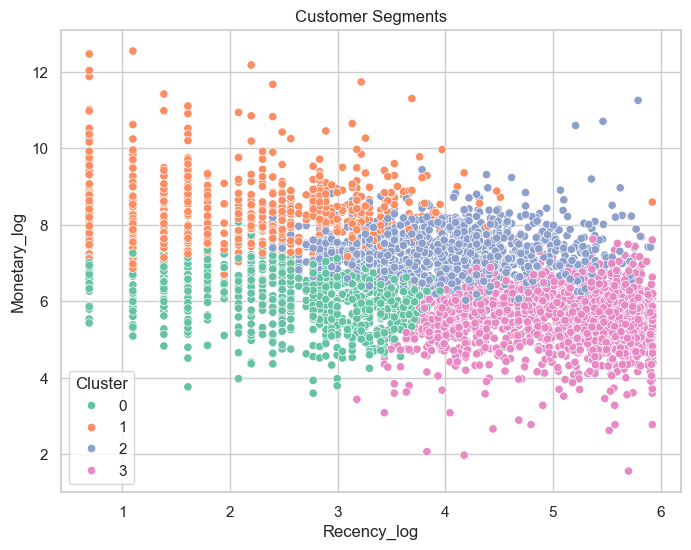

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=rfm['Recency_log'],
    y=rfm['Monetary_log'],
    hue=rfm['Cluster'],
    palette='Set2'
)
plt.title("Customer Segments")
plt.show()

## (10) Silhouette Score

In [13]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, rfm['Cluster'])
print("Silhourtte Score:", score)

Silhourtte Score: 0.3371343622222519


## (11) Save the result

In [14]:
rfm.to_csv("C:/Projects/08_Customer_Intellignece_System/data/customer_segments.csv", index=False)